# Compare historical observations and coverage

Compare water temperatures at a Boston buoy and a Caribbean buoy, calculate measurement coverage, and save the original dataset. The two stations illustrate contrasting locations, rather than a spatially continuous temperature field.

Saved outputs use NOAA observations. Execution began 2026-09-10 13:38 UTC. Re-running requests current upstream data.

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import xndbc

station_ids = ["44013", "41043"]
year = 2020

## Download a small station selection

Use fixed IDs and a fixed year so the example has a clear scope. Use station discovery to build your own selection.

In [2]:
data = xndbc.fetch_historical(station_ids, years=year, progress=False)
data.ndbc.report()

<xarray.Dataset> Size: 664B
Dimensions:     (request: 2)
Coordinates:
  * request     (request) int64 16B 0 1
Data variables:
    station_id  (request) <U5 40B '44013' '41043'
    url         (request) <U66 528B 'https://www.ndbc.noaa.gov/data/historica...
    status      (request) <U7 56B 'success' 'success'
    error       (request) <U1 8B '' ''
    year        (request) float64 16B 2.02e+03 2.02e+03
Attributes:
    description:  Original download request outcomes; year is missing for rea...

## Compare monthly water temperatures

Select only water temperature before averaging. This keeps the operation explicit and avoids accidentally applying ordinary means to directional measurements.

In [3]:
monthly = data.WTMP.resample(time="ME").mean(keep_attrs=True)
monthly

<xarray.DataArray 'WTMP' (station_id: 2, time: 13)> Size: 208B
array([[ 6.9       ,  6.43837838,  5.17910015,  5.58119891,  6.51506276,
         9.94366577, 16.72033898, 21.01342383, 20.16331034, 18.03615819,
        13.92091503, 11.10223409,  8.39410043],
       [        nan,         nan,         nan,         nan,         nan,
        28.24905183, 28.6642574 , 29.09892627, 29.10361011, 29.39160448,
        29.09830125, 28.18204319, 27.44421171]])
Coordinates:
  * station_id    (station_id) object 16B '44013' '41043'
    latitude      (station_id) float64 16B 42.35 21.09
    longitude     (station_id) float64 16B -70.65 -64.86
    name          (station_id) <U76 608B 'BOSTON 16 NM East of Boston, MA' 'N...
    owner         (station_id) <U3 24B 'N' 'N'
    station_type  (station_id) <U40 320B '2.1-meter ionomer foam buoy' '3-met...
    notes         (station_id) <U990 8kB 'Caution: Right whales may be active...
  * time          (time) datetime64[ns] 104B 2019-12-31 ... 2020-12-31
Attributes:
    long_name:  Water temperature
    units:      degC

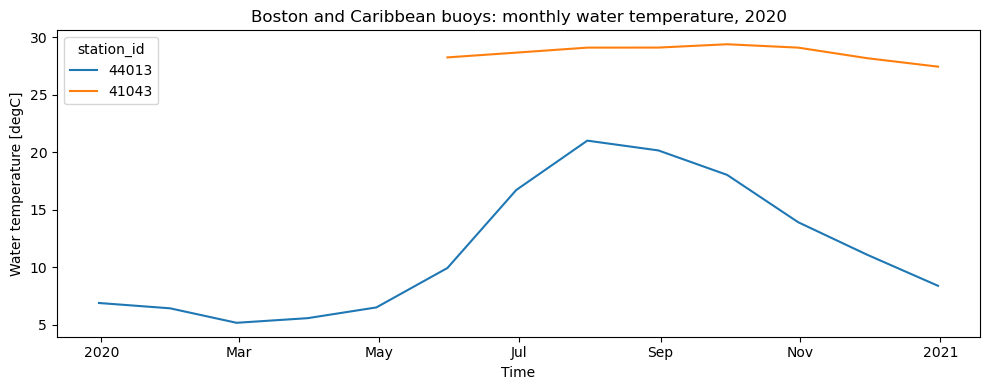

In [4]:
monthly.plot.line(x="time", hue="station_id", figsize=(10, 4))
plt.title(f"Boston and Caribbean buoys: monthly water temperature, {year}")
plt.tight_layout()
plt.show()

## Measure daily coverage

Coverage is the percentage of days containing at least one valid water-temperature observation. It is not the percentage of expected native samples. Use the original data, before averaging, and specify the full year so missing days at either end count.

In [5]:
coverage = data[["WTMP"]].ndbc.coverage(
    "D", start=f"{year}-01-01", end=f"{year}-12-31T23:59:59"
)
coverage

<xarray.Dataset> Size: 9kB
Dimensions:       (station_id: 2)
Coordinates:
  * station_id    (station_id) object 16B '44013' '41043'
    latitude      (station_id) float64 16B 42.35 21.09
    longitude     (station_id) float64 16B -70.65 -64.86
    name          (station_id) <U76 608B 'BOSTON 16 NM East of Boston, MA' 'N...
    owner         (station_id) <U3 24B 'N' 'N'
    station_type  (station_id) <U40 320B '2.1-meter ionomer foam buoy' '3-met...
    notes         (station_id) <U990 8kB 'Caution: Right whales may be active...
Data variables:
    WTMP          (station_id) float64 16B 100.0 61.75
Attributes:
    frequency:     D
    window_start:  2020-01-01T00:00:00.000000000
    window_end:    2020-12-31T23:59:59.000000000
    time_bins:     366
    definition:    Percent of bins containing at least one nonmissing observa...

## Put coverage on a map

The map receives one value per station. Its colors describe measurement coverage, not water temperature.

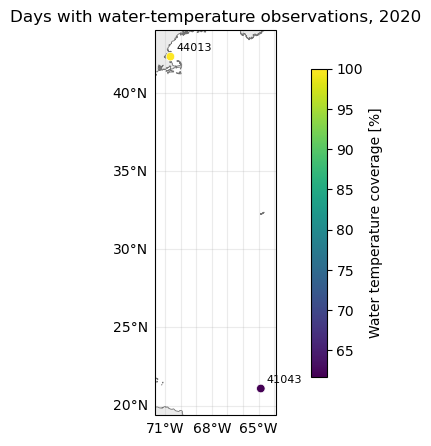

In [6]:
fig, ax = xndbc.stations.plot_map(coverage, variable="WTMP")
ax.set_title(f"Days with water-temperature observations, {year}")
plt.show()

## Save and reopen the observations

xarray writes NetCDF directly. This cell creates `historical_observations.nc` in the working directory and uses SciPy, which is installed with xndbc. The original observations, attributes, and download report survive the round trip.

In [7]:
data.to_netcdf("historical_observations.nc", engine="scipy")

with xr.open_dataset("historical_observations.nc", engine="scipy") as saved:
    restored = saved.load()

restored.ndbc.report()

<xarray.Dataset> Size: 664B
Dimensions:     (request: 2)
Coordinates:
  * request     (request) int64 16B 0 1
Data variables:
    station_id  (request) <U5 40B '44013' '41043'
    url         (request) <U66 528B 'https://www.ndbc.noaa.gov/data/historica...
    status      (request) <U7 56B 'success' 'success'
    error       (request) <U1 8B '' ''
    year        (request) float64 16B 2.02e+03 2.02e+03
Attributes:
    description:  Original download request outcomes; year is missing for rea...

The saved dataset can be analyzed later without another NOAA request. Use fetch_realtime() to load recent observations.